# Lecture 10: Density estimation

<div class="alert alert-success">
2d density estimation using a single Gaussian, a Mixture Density Network, and a Normalizing Flow.
</div>

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

torch.manual_seed(42)
np.random.seed(42)

## Data

In [ ]:
from sklearn.datasets import make_moons

X_np, _ = make_moons(n_samples=10000, noise=0.05)
X_train = torch.tensor(X_np, dtype=torch.float32)

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(X_train[:, 0], X_train[:, 1], alpha=0.1, s=1)
plt.show()

In [49]:
def plot_model(model, title, n_samples=5000, grid_res=200):
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    
    xx, yy = torch.meshgrid(
        torch.linspace(-2, 3, grid_res),
        torch.linspace(-2.5, 2.5, grid_res),
        indexing='xy')
    
    grid = torch.stack([xx.flatten(), yy.flatten()], dim=1)
    with torch.no_grad():
        log_p = model.log_prob(grid)
    log_p = log_p.reshape(grid_res, grid_res)

    axes[0].contourf(xx.numpy(), yy.numpy(), log_p.exp().numpy(), levels=20, cmap='viridis')
    axes[0].scatter(X_train[:, 0], X_train[:, 1], alpha=0.05, s=1, c='white')
    axes[0].set_aspect('equal')
    axes[0].set_title(f'{title}: density')

    with torch.no_grad():
        samples = model.sample(n_samples).numpy()
    axes[1].scatter(samples[:, 0], samples[:, 1], alpha=0.1, s=1)
    axes[1].set_aspect('equal')
    axes[1].set_title(f'{title}: samples')
    axes[1].set_xlim(-2, 3)
    axes[1].set_ylim(-2.5, 2.5)

## Single Gaussian

The maximum likelihood Gaussian fit: $p(\mathbf{x}) = \mathcal{N}(\mathbf{x} \mid \hat{\boldsymbol{\mu}}, \hat{\boldsymbol{\Sigma}})$.

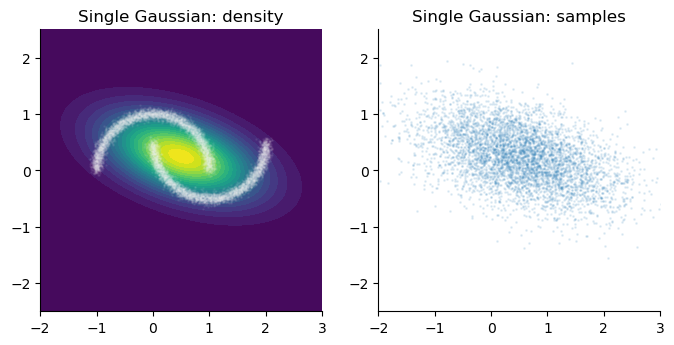

In [50]:
class SingleGaussian:
    def __init__(self, data):
        self.mu = data.mean(0)
        centered = data - self.mu
        self.cov = (centered.T @ centered) / len(data)
        self.dist = torch.distributions.MultivariateNormal(self.mu, self.cov)

    def log_prob(self, x):
        return self.dist.log_prob(x)

    def sample(self, n):
        return self.dist.sample((n,))

gaussian = SingleGaussian(X_train)
plot_model(gaussian, 'Single Gaussian')

## Gaussian Mixture Model

$$p(\mathbf{x}) = \sum_{k=1}^{K} \pi_k \, \mathcal{N}(\mathbf{x} \mid \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$$

We learn the mixture weights, means, and (diagonal) covariances by maximizing the log-likelihood via gradient descent. With enough components, the GMM can tile the two moons — but it approximates the density with local blobs rather than capturing the global shape.

  epoch 100: nll=0.488
  epoch 200: nll=0.434
  epoch 300: nll=0.408


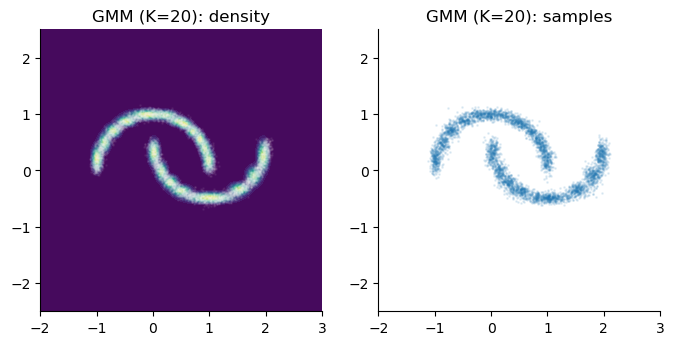

In [53]:
class GMM(nn.Module):
    def __init__(self, K=20, D=2):
        super().__init__()
        self.K = K
        self.logits = nn.Parameter(torch.zeros(K))        
        self.mus = nn.Parameter(torch.randn(K, D) * 0.5)  
        self.log_stds = nn.Parameter(torch.zeros(K, D))   

    def log_prob(self, x):
        log_pi = F.log_softmax(self.logits, dim=0)           
        stds = self.log_stds.exp()                          
        diff = x.unsqueeze(1) - self.mus.unsqueeze(0)      
        log_comp = -0.5 * ((diff / stds) ** 2 + 2 * self.log_stds + np.log(2 * np.pi)).sum(-1) 
        return torch.logsumexp(log_comp + log_pi, dim=-1)   

    @torch.no_grad()
    def sample(self, n):
        pi = F.softmax(self.logits, dim=0)
        k = torch.multinomial(pi.expand(n, -1), 1).squeeze(-1)
        mu = self.mus[k]
        std = self.log_stds[k].exp()
        return mu + std * torch.randn_like(mu)


K = 20
gmm = GMM(K=K)
optimizer = torch.optim.Adam(gmm.parameters(), lr=1e-2)

for epoch in range(300):
    perm = torch.randperm(len(X_train))
    for i in range(0, len(X_train), 256):
        idx = perm[i:i+256]
        loss = -gmm.log_prob(X_train[idx]).mean()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    if (epoch + 1) % 100 == 0:
        nll = -gmm.log_prob(X_train).mean().item()
        print(f'  epoch {epoch+1}: nll={nll:.3f}')

plot_model(gmm, f'GMM (K={K})')

## Normalizing Flow (RealNVP)

A normalizing flow maps a simple base density $p_Z(\mathbf{z}) = \mathcal{N}(\mathbf{0}, \mathbf{I})$ through an invertible function $\mathbf{x} = f(\mathbf{z})$:

$$p(\mathbf{x}) = p_Z(f^{-1}(\mathbf{x})) \left| \det \frac{\partial f^{-1}}{\partial \mathbf{x}} \right|$$

Each **affine coupling layer** splits the input into two halves $(\mathbf{x}_a, \mathbf{x}_b)$ and transforms one conditioned on the other:
$$\mathbf{x}_b' = \mathbf{x}_b \odot \exp(s(\mathbf{x}_a)) + t(\mathbf{x}_a)$$

Since $s$ and $t$ are arbitrary neural networks, the transformation is expressive. For 2D data, each layer transforms one coordinate conditioned on the other, and we alternate which coordinate is transformed.

  epoch 100: nll=0.424
  epoch 200: nll=0.350
  epoch 300: nll=0.352


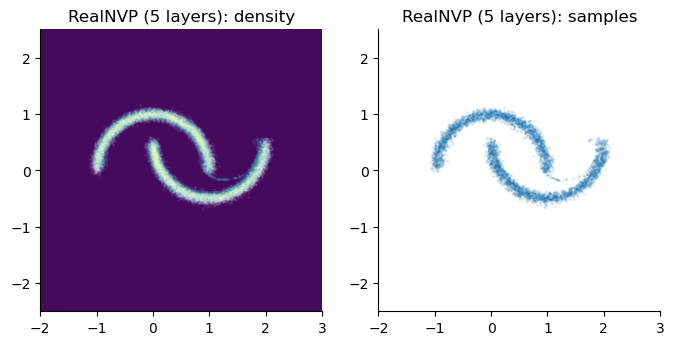

In [54]:
class CouplingLayer(nn.Module):
    def __init__(self, flip, hidden_dim=64):
        super().__init__()
        self.flip = flip
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim), 
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), 
            nn.ReLU(),
            nn.Linear(hidden_dim, 2), 
        )

    def forward(self, x):
        if self.flip:
            xa, xb = x[:, 1:], x[:, :1]
        else:
            xa, xb = x[:, :1], x[:, 1:]

        params = self.net(xa)
        log_s, t = params[:, :1], params[:, 1:]
        yb = xb * log_s.exp() + t

        if self.flip:
            return torch.cat([yb, xa], dim=1), log_s.squeeze(-1)
        else:
            return torch.cat([xa, yb], dim=1), log_s.squeeze(-1)

    def inverse(self, z):
        if self.flip:
            za, zb = z[:, 1:], z[:, :1]
        else:
            za, zb = z[:, :1], z[:, 1:]

        params = self.net(za)
        log_s, t = params[:, :1], params[:, 1:]
        xb = (zb - t) * (-log_s).exp()

        if self.flip:
            return torch.cat([xb, za], dim=1)
        else:
            return torch.cat([za, xb], dim=1)


class RealNVP(nn.Module):
    def __init__(self, n_layers=8, hidden_dim=64):
        super().__init__()
        self.layers = nn.ModuleList([
            CouplingLayer(flip=(i % 2 == 1), hidden_dim=hidden_dim)
            for i in range(n_layers)
        ])

    def forward(self, x):
        log_det = 0
        z = x
        for layer in self.layers:
            z, ld = layer(z)
            log_det = log_det + ld
        return z, log_det

    def log_prob(self, x):
        z, log_det = self.forward(x)
        log_pz = -0.5 * (z ** 2 + np.log(2 * np.pi)).sum(-1)
        return log_pz + log_det

    @torch.no_grad()
    def sample(self, n):
        z = torch.randn(n, 2)
        x = z
        for layer in reversed(self.layers):
            x = layer.inverse(x)
        return x


flow = RealNVP(n_layers=5, hidden_dim=64)
optimizer = torch.optim.Adam(flow.parameters(), lr=1e-3)

for epoch in range(300):
    perm = torch.randperm(len(X_train))
    for i in range(0, len(X_train), 256):
        idx = perm[i:i+256]
        loss = -flow.log_prob(X_train[idx]).mean()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    if (epoch + 1) % 100 == 0:
        nll = -flow.log_prob(X_train).mean().item()
        print(f'  epoch {epoch+1}: nll={nll:.3f}')

plot_model(flow, 'RealNVP (5 layers)')

We can see how the flow warps the Gaussian base density step by step through its layers.

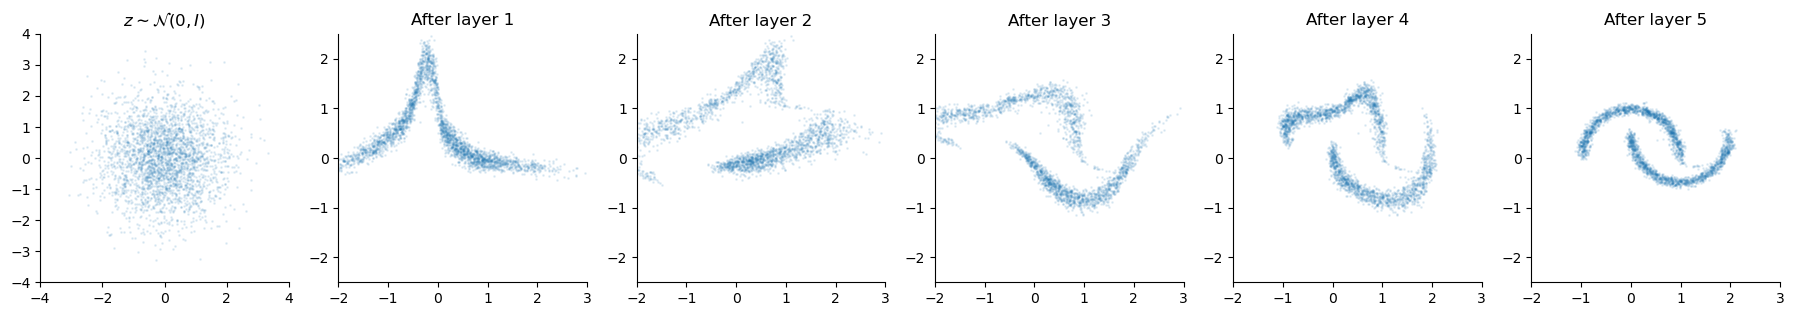

In [56]:
flow.eval()
z = torch.randn(3000, 2)

n_layers = len(flow.layers)
fig, axes = plt.subplots(1, n_layers + 1, figsize=(3 * (n_layers + 1), 3))

with torch.no_grad():
    x = z.clone()
    axes[0].scatter(x[:, 0], x[:, 1], alpha=0.1, s=1)
    axes[0].set_title(r'$z \sim \mathcal{N}(0, I)$')
    axes[0].set_aspect('equal')
    axes[0].set_xlim(-4, 4)
    axes[0].set_ylim(-4, 4)

    for i, layer in enumerate(reversed(flow.layers)):
        x = layer.inverse(x)
        axes[i + 1].scatter(x[:, 0], x[:, 1], alpha=0.1, s=1)
        axes[i + 1].set_title(f'After layer {i + 1}')
        axes[i + 1].set_aspect('equal')
        axes[i + 1].set_xlim(-2, 3)
        axes[i + 1].set_ylim(-2.5, 2.5)

plt.tight_layout()